<a href="https://colab.research.google.com/github/marcinwolter/Varia/blob/main/unet_triangle_localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U-Net Triangle Localization Demo
Trains a small U-Net to detect triangles (but not circles) in synthetic images.

1.04.2026 M.W. with a help of claude.ai

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 128
N_TRAIN = 800
N_VAL   = 100
EPOCHS  = 15
BATCH   = 16
print("Libraries loaded.")

Libraries loaded.


## 1. Data Generation

In [24]:
def rotate_points(pts, angle, center=None):
    pts = pts.astype(float)

    if center is None:
        center = pts.mean(axis=0)  # centroid

    cx, cy = center

    # rotation matrix
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    # shift → rotate → shift back
    shifted = pts - [cx, cy]
    rotated = shifted @ R.T
    return (rotated + [cx, cy]).astype(np.int32)

def draw_triangle(img, mask, cx, cy, size, color):
    """Draw a filled triangle and mark its bounding region on the mask."""
    h = int(size * np.sqrt(3) / 2)
    pts = np.array([
        [cx,          cy - h // 2],
        [cx - size//2, cy + h // 2],
        [cx + size//2, cy + h // 2]
    ], dtype=np.int32)
    # rotate triangle
    alpha = np.pi / 6  # 30 degrees
    alpha = np.random.uniform(-alpha, alpha)
    rotated_pts = rotate_points(pts, alpha)

    cv2.fillPoly(img,  [rotated_pts], color)
    cv2.fillPoly(mask, [rotated_pts], 1)   # mask = 1 where triangle


def draw_circle(img, cx, cy, radius, color):
    """Draw a filled circle (NOT added to mask)."""
    cv2.circle(img, (cx, cy), radius, color, -1)


def generate_image(img_size=IMG_SIZE, n_shapes=(2, 5)):
    img  = np.zeros((img_size, img_size, 3), dtype=np.float32)
    mask = np.zeros((img_size, img_size, 1), dtype=np.float32)

    n = np.random.randint(*n_shapes)
    for _ in range(n):
        size   = np.random.randint(12, 28)
        margin = size
        cx = np.random.randint(margin, img_size - margin)
        cy = np.random.randint(margin, img_size - margin)
        color = [np.random.uniform(0.4, 1.0) for _ in range(3)]

        if np.random.rand() > 0.5:
            draw_triangle(img, mask, cx, cy, size, color)
        else:
            draw_circle(img, cx, cy, size // 2, color)

    # light noise background
    img = np.clip(img + np.random.normal(0, 0.03, img.shape), 0, 1).astype(np.float32)
    return img, mask


def generate_dataset(n, img_size=IMG_SIZE):
    imgs, masks = [], []
    for _ in range(n):
        img, mask = generate_image(img_size)
        imgs.append(img)
        masks.append(mask)
    return np.array(imgs), np.array(masks)


X_train, Y_train = generate_dataset(N_TRAIN)
X_val,   Y_val   = generate_dataset(N_VAL)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (800, 128, 128, 3), Val: (100, 128, 128, 3)


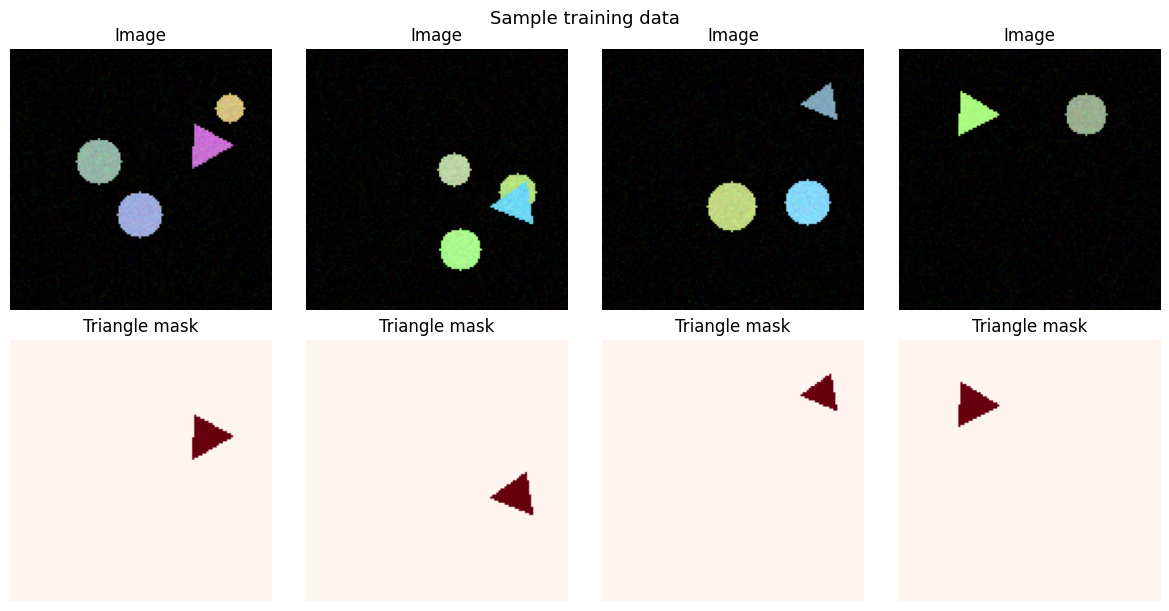

In [25]:
# Quick peek at the training data
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(Y_train[i, :, :, 0], cmap="Reds")
    axes[1, i].set_title("Triangle mask")
    axes[1, i].axis("off")
plt.tight_layout()
plt.suptitle("Sample training data", y=1.01, fontsize=13)
plt.show()

## 2. Tiny U-Net Model

In [26]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


def build_unet(img_size=IMG_SIZE, base_filters=16):
    inp = keras.Input((img_size, img_size, 3))

    # Encoder
    c1 = conv_block(inp, base_filters)          # 128
    p1 = layers.MaxPooling2D()(c1)              # 64
    c2 = conv_block(p1, base_filters * 2)       # 64
    p2 = layers.MaxPooling2D()(c2)              # 32

    # Bottleneck
    bn = conv_block(p2, base_filters * 4)       # 32

    # Decoder
    u3 = layers.UpSampling2D()(bn)              # 64
    u3 = layers.Concatenate()([u3, c2])
    c3 = conv_block(u3, base_filters * 2)

    u4 = layers.UpSampling2D()(c3)              # 128
    u4 = layers.Concatenate()([u4, c1])
    c4 = conv_block(u4, base_filters)

    out = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    model = keras.Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.MeanIoU(num_classes=2, name="iou")]
    )
    return model


model = build_unet()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_33[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_35[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_37[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 64, 64,    │          0 │ conv2d_38[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 96)               │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │     27,680 │ concatenate_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_39[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 128, 128,  │          0 │ conv2d_40[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 128, 128,  │          0 │ up_sampling2d_7[… │
│ (Concatenate)       │ 48)               │            │ conv2d_34[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │      6,928 │ concatenate_7[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_41[0][0] 

 Total params: 118,273 (462.00 KB)

 Trainable params: 118,273 (462.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [27]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=callbacks
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9678 - iou: 0.4915 - loss: 0.1738 - val_accuracy: 0.9821 - val_iou: 0.4911 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9832 - iou: 0.4915 - loss: 0.0295 - val_accuracy: 0.9830 - val_iou: 0.4911 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9898 - iou: 0.4915 - loss: 0.0214 - val_accuracy: 0.9951 - val_iou: 0.4911 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9968 - iou: 0.4915 - loss: 0.0091 - val_accuracy: 0.9977 - val_iou: 0.4911 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9981 - iou: 0.4915 - loss: 0.0057 - val_accuracy: 0.9981 - val_iou: 0.4911 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9985 - iou: 0.4915 

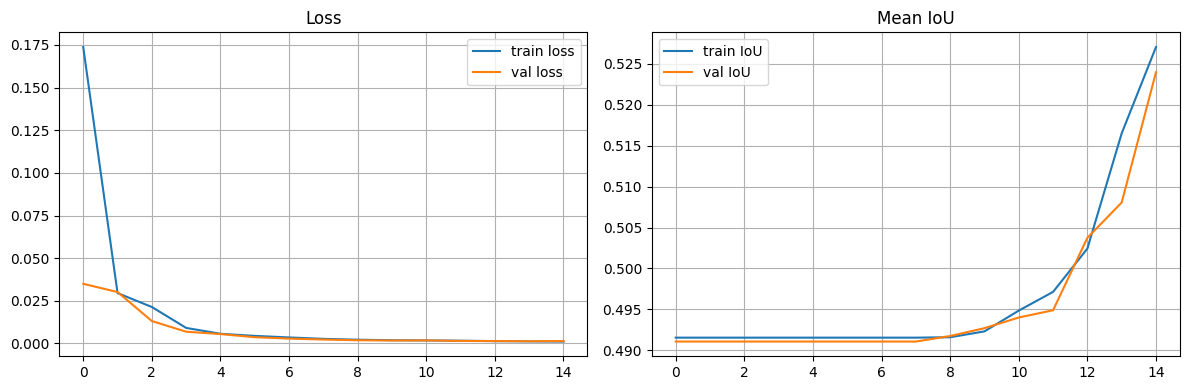

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["iou"],     label="train IoU")
axes[1].plot(history.history["val_iou"], label="val IoU")
axes[1].set_title("Mean IoU"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

## 4. Inference & Visualization

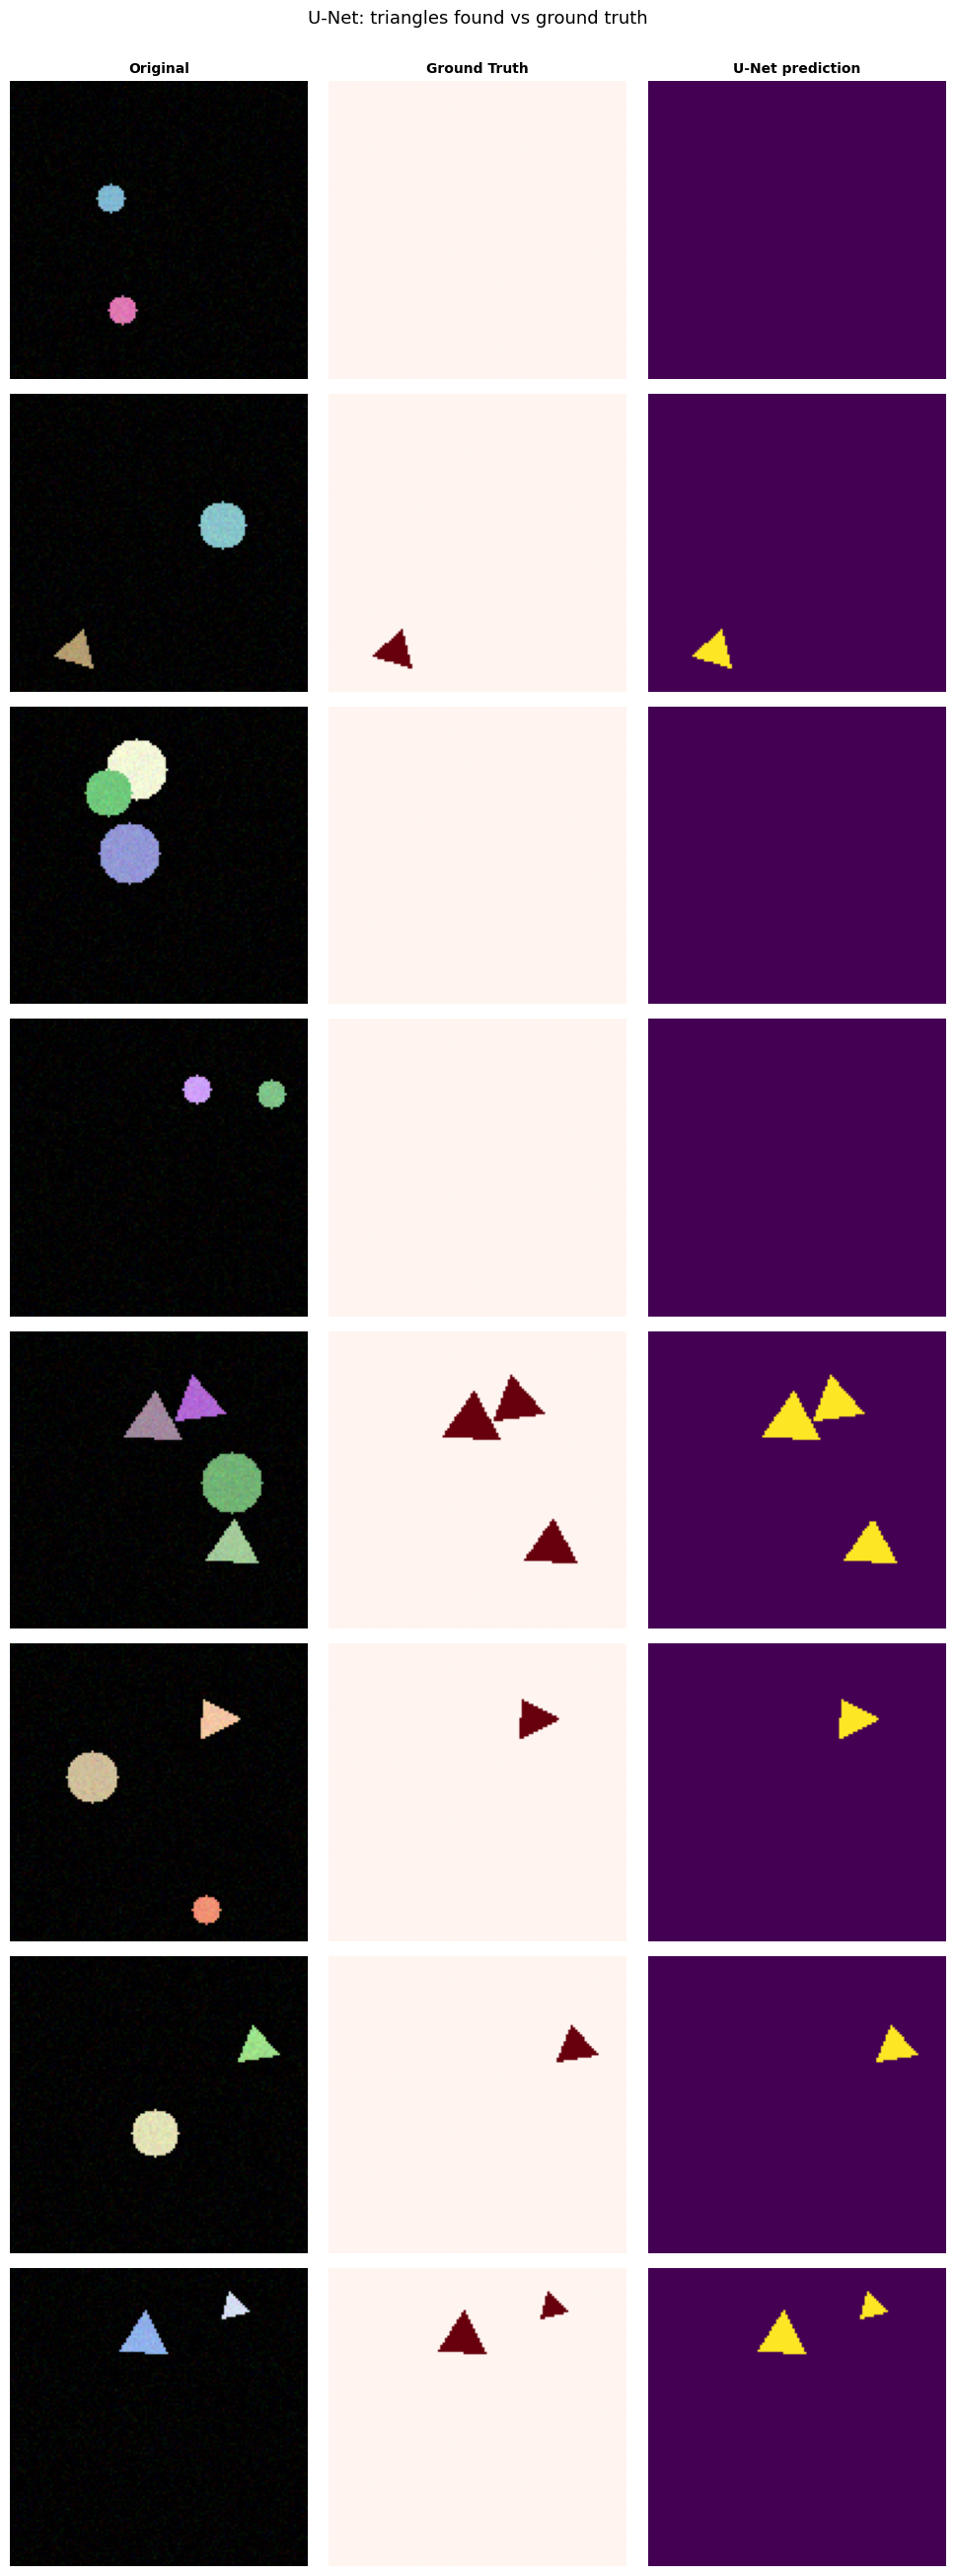

In [29]:
# Generate fresh test images
X_test, Y_test = generate_dataset(8)
preds = model.predict(X_test, verbose=0)   # shape (8, 128, 128, 1)

THRESHOLD = 0.4

fig, axes = plt.subplots(8, 3, figsize=(10, 26))
col_titles = ["Original", "Ground Truth", "U-Net prediction"]

for i in range(8):
    img   = X_test[i]
    gt    = Y_test[i, :, :, 0]
    pred  = preds[i, :, :, 0]

    # --- overlay predicted mask as light red ---
    overlay = img.copy()
    heat = (pred > THRESHOLD).astype(np.float32)
    # blend: push R channel up, suppress G and B slightly
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + 0.55 * heat, 0, 1)
    #overlay[:, :, 0] = np.clip(overlay[:, :, 0] , 0, 1)
    overlay[:, :, 1] = np.clip(overlay[:, :, 1] - 0.25 * heat, 0, 1)
    overlay[:, :, 2] = np.clip(overlay[:, :, 2] - 0.25 * heat, 0, 1)

    axes[i, 0].imshow(img);     axes[i, 0].axis("off")
    axes[i, 1].imshow(gt, cmap="Reds", vmin=0, vmax=1); axes[i, 1].axis("off")
    #axes[i, 2].imshow(overlay); axes[i, 2].axis("off")
    axes[i, 2].imshow(heat); axes[i, 2].axis("off")

    if i == 0:
        for j, t in enumerate(col_titles):
            axes[0, j].set_title(t, fontsize=10, fontweight="bold")

plt.suptitle("U-Net: triangles found vs ground truth", fontsize=13, y=1.002)
plt.tight_layout()
plt.show()